# Session 4: Reducing the Time Dimension
**MOOC Series: From Satellite Data to Insights with Digital Earth Sweden**

---

## Session outline

- Quick recap: the four dimensions of a datacube (x, y, bands, time) — introduced in Session 2
- Modifying a datacube by reducing a dimension: what it means and why you need it
- Practical examples: reducing the temporal dimension with the first, mean, median, and max reducers

By the end of this session you will be able to use `reduce_dimension` to modify a datacube, collapsing its time dimension to transform multi-temporal image stacks into single summary layers.

---

## 1. Setup

In [1]:
import openeo
import io
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Connect to Digital Earth Sweden
connection = openeo.connect('https://openeo.digitalearth.se')
connection.authenticate_basic(username='testuser', password='secretpassword')

print('Connected to Digital Earth Sweden.')

Connected to Digital Earth Sweden.


## 2. Recap: the four dimensions of a datacube

In Session 2 you loaded a Sentinel-2 datacube and saw that it is a **four-dimensional** object:

[![Datacube Timeseries](https://openeo.org/assets/img/dc_timeseries.c2c7a902.png)](https://openeo.org/assets/img/dc_timeseries.c2c7a902.png)

| Dimension | Label in openEO | What it represents |
|---|---|---|
| East–West | `x` | Longitude or easting |
| North–South | `y` | Latitude or northing |
| Spectral | `bands` | Wavelength channel (e.g. `B02`, `B04`) |
| Temporal | `t` | Acquisition date/time |

---

## 3. Modifying a datacube: what is dimension reduction?

**Reducing a dimension** means collapsing it by applying a summary function (mean, median, max, sum, …) across all values along that dimension. The result is a datacube with one fewer dimension — this is one of the most common ways to *modify* a datacube.

![Reduction illustration](https://openeo.org/assets/img/dc_reduce.872f16c2.png)

*Image credit: openEO.org*

In this session we focus on reducing the **temporal** dimension:

| Reducer | What you get |
|---|---|
| `first` | The first acquired image in the time series (no summarization) |
| `mean` | An average image over the period |
| `median` | A single cloud-free composite image |
| `max` | The brightest pixel at each location across all dates |

## 4. Loading a multi-temporal datacube

To demonstrate reduction, we need a datacube with more than one time step. We load all Sentinel-2 scenes acquired over Karlstad in **June 2026**. There will typically be 5–15 cloud-free scenes in this period depending on weather.

In [2]:
# Area of interest: Karlstad, Sweden
aoi = {
    'west':  13.460930954751282,
    'east':  13.585449709728213,
    'south': 59.36327761288911,
    'north': 59.40107161575003,
    'crs':   'EPSG:4326',
}
timespan = ['2026-06-01', '2026-07-01']

# Load Sentinel-2 datacube with Red and NIR bands
datacube = connection.load_collection(
    collection_id='des_s2_msi_l2a',
    spatial_extent=aoi,
    temporal_extent=timespan,
    bands=['B02', 'B03', 'B04', 'B08'],
    properties = {'eo:cloud_cover': lambda x: x <= 20},
)
print('Multi-temporal datacube defined.')

Multi-temporal datacube defined.


## 5. Reducing the time dimension

### 5a. First image in the series

The simplest way to reduce the time dimension is the `first` reducer, which just picks the first acquired image at each pixel location — no averaging or comparison across dates involved. It's not a summary statistic, but it's a quick way to pull a single representative scene out of a multi-temporal datacube, e.g. for a fast preview before running a more expensive reducer like `mean` or `median`.

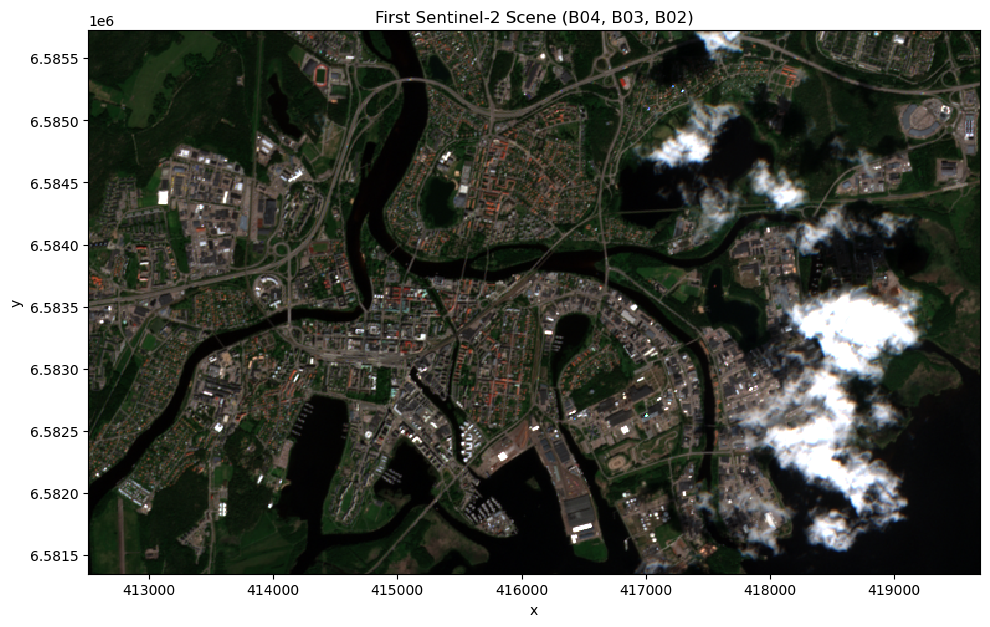

In [3]:
# Reduce the time dimension by selecting the first image in the series
first_image = datacube.reduce_dimension(dimension='t', reducer='first')
first_tif = first_image.download(format='GTiff')

# Load into xarray
da = xr.open_dataarray(io.BytesIO(first_tif), engine='rasterio')
da = da.assign_coords(band=['B02', 'B03', 'B04', 'B08'])
da = (da.astype(np.float32) / 10_000).clip(0, 1)

# True color visualization
rgb = da.sel(band=['B04', 'B03', 'B02'])
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
rgb.plot.imshow(rgb='band', vmin=0, vmax=0.4, ax=ax)
ax.set_aspect('equal')
ax.set_title('First Sentinel-2 Scene (B04, B03, B02)')
plt.tight_layout()
plt.show()

### 5b. Mean over time

Taking the **mean** over all time steps gives us an average image for the period. For each pixel location, we average all observed reflectance values. This is a quick way to summarize the period but is sensitive to cloud contamination.

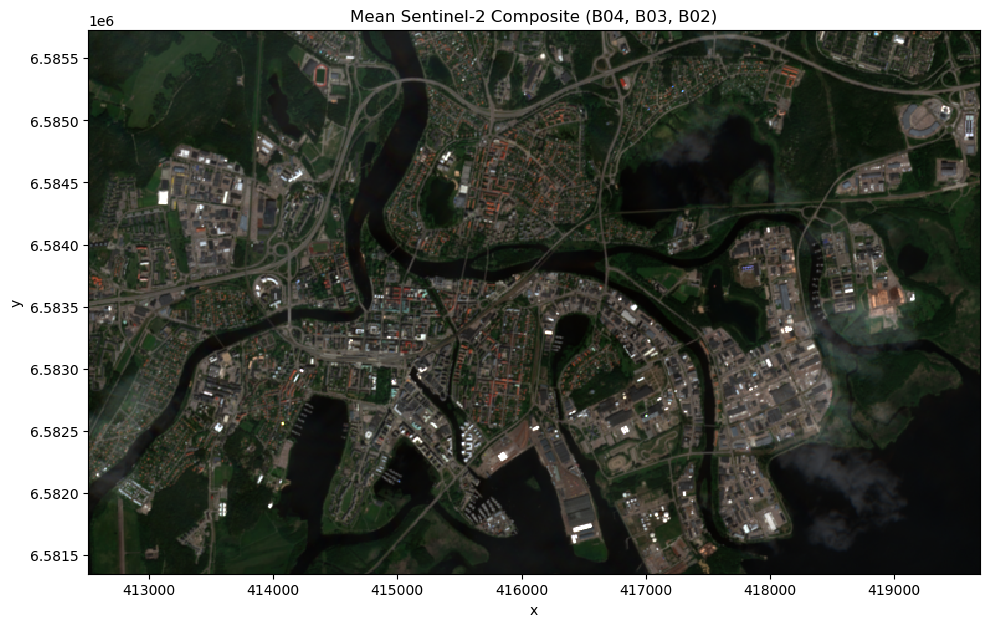

In [4]:
# Reduce the time dimension by computing the per-pixel mean
mean_image = datacube.reduce_dimension(dimension='t', reducer='mean')
mean_tif = mean_image.download(format='GTiff')

# Load into xarray
da = xr.open_dataarray(io.BytesIO(mean_tif), engine='rasterio')
da = da.assign_coords(band=['B02', 'B03', 'B04', 'B08'])
da = (da.astype(np.float32) / 10_000).clip(0, 1)

# True color visualization
rgb = da.sel(band=['B04', 'B03', 'B02'])
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
rgb.plot.imshow(rgb='band', vmin=0, vmax=0.4, ax=ax)
ax.set_aspect('equal')
ax.set_title('Mean Sentinel-2 Composite (B04, B03, B02)')
plt.tight_layout()
plt.show()

### 5c. Median over time

The **median** is often preferable to the mean for satellite compositing because it is robust to outliers like clouds, shadows, and sun glint. We will study this in detail in Session 5 (cloud compositing).

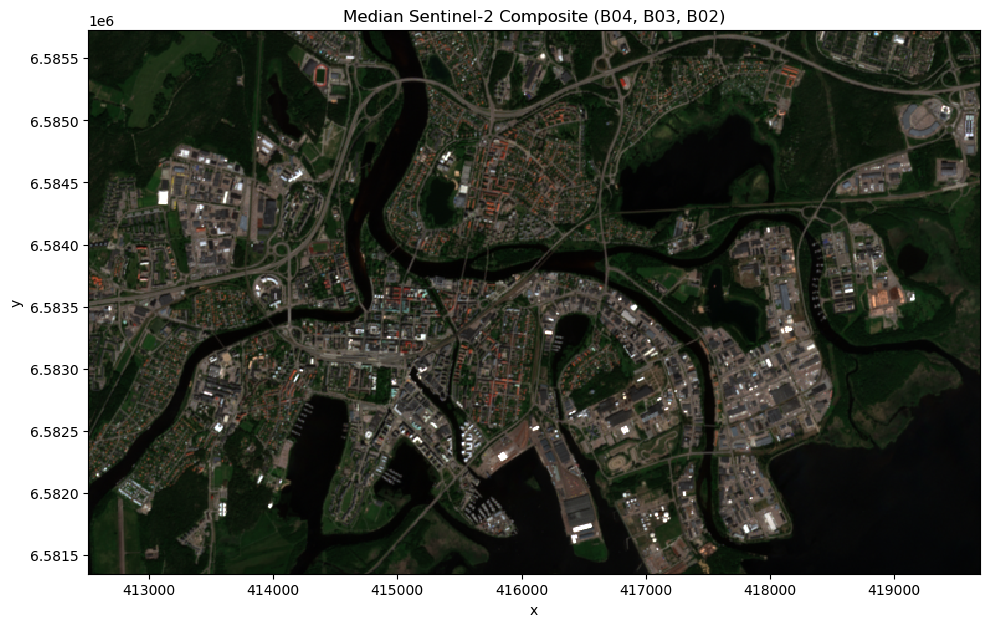

In [5]:
# Reduce the time dimension using the median (more robust than mean for cloud removal)
median_image = datacube.reduce_dimension(dimension='t', reducer='median')
median_tif = median_image.download(format='GTiff')

# Load into xarray
da = xr.open_dataarray(io.BytesIO(median_tif), engine='rasterio')
da = da.assign_coords(band=['B02', 'B03', 'B04', 'B08'])
da = (da.astype(np.float32) / 10_000).clip(0, 1)

# True color visualization
rgb = da.sel(band=['B04', 'B03', 'B02'])
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
rgb.plot.imshow(rgb='band', vmin=0, vmax=0.4, ax=ax)
ax.set_aspect('equal')
ax.set_title('Median Sentinel-2 Composite (B04, B03, B02)')
plt.tight_layout()
plt.show()

### 5d. Maximum over time (greenness peak)

The **maximum** over time selects the highest NDVI value at each location across the time series. This typically corresponds to the peak-summer scene when vegetation is greenest and most dense — a useful measure of maximum vegetation potential.

We compute NDVI for every scene in the datacube (as learned in Session 3) and then reduce the time dimension using the `max` reducer.

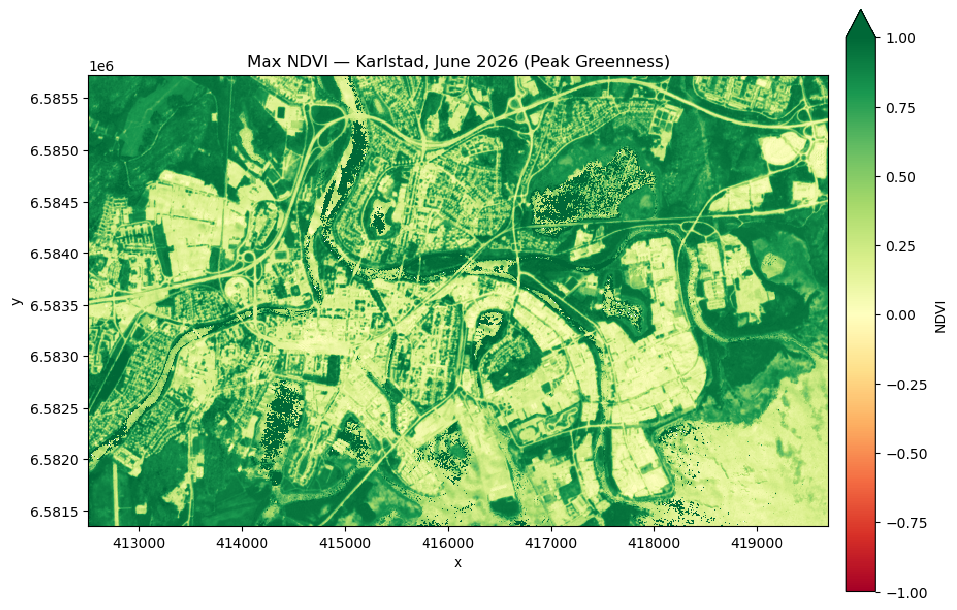

In [6]:
# Compute NDVI for every scene in the datacube (as learned in Session 3)
ndvi_datacube = datacube.ndvi(nir='B08', red='B04')

# Maximum NDVI over the period (proxy for maximum vegetation greenness)
max_ndvi_image = ndvi_datacube.reduce_dimension(dimension='t', reducer='max')
max_ndvi_tif = max_ndvi_image.download(format='GTiff')

# Load into xarray
max_ndvi_da = xr.open_dataarray(io.BytesIO(max_ndvi_tif), engine='rasterio').squeeze()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
cbar_kwargs = {'shrink': 0.6, 'aspect': 20, 'pad': 0.02, 'label': 'NDVI'}
max_ndvi_da.plot.imshow(ax=ax, cmap='RdYlGn', cbar_kwargs=cbar_kwargs, vmin=-1, vmax=1)
ax.set_aspect('equal')
ax.set_title('Max NDVI — Karlstad, June 2026 (Peak Greenness)')
plt.tight_layout()
plt.show()

## Summary

In this session you:

- Recapped the four dimensions of a Sentinel-2 datacube (x, y, bands, time) from Session 2.
- Modified a datacube by using `reduce_dimension` to collapse its time dimension with the first, mean, median, and max reducers.
- Computed NDVI across a multi-scene datacube and reduced it over time to find the peak-greenness composite.

**Next session:** we address a major practical challenge in optical EO — clouds. You will learn to detect and mask cloudy pixels using the Quality Assurance Information (AQI) layer, and combine masking with temporal reduction to produce a clean, cloud-free composite.

---
*Digital Earth Sweden MOOC — Session 4 of 6*